In [1]:
#import require python classes and packages
from Gan.model import generator_model #loading GAN model classes
from Gan.utils import load_image, deprocess_image, preprocess_image, load_images
from PIL import Image
import os
import numpy as np
import cv2
from keras.preprocessing.image import ImageDataGenerator, load_img,img_to_array
from sklearn.metrics import confusion_matrix #class to calculate accuracy and other metrics
import matplotlib.pyplot as plt
import seaborn as sns
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, BatchNormalization
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
import pickle
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
C:\Users\Dell\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\Dell\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\Dell\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users\Dell\AppData\Roaming

In [2]:
#define global variables
labels = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
no_aug_X = []
no_aug_Y = []
traditional_aug_X = []
traditional_aug_Y = []
advance_aug_X = []
advance_aug_Y = []

In [3]:
#function to get integer class label for given crop disease
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            break
    return index

In [4]:
#load normal plain dataset without augmentation
#loop and read all images from dataset
if os.path.exists('model/X.txt.npy'):#if images already processed then load all images
    no_aug_X = np.load('model/X.txt.npy')
    no_aug_Y = np.load('model/Y.txt.npy')
else:#if not processed then read and process each image
    no_aug_X = []
    no_aug_Y = []
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j])#read image
                img = cv2.resize(img, (32, 32))#resize image
                no_aug_X.append(img)#addin images features to training array
                label = getLabel(name)
                no_aug_Y.append(label)
    no_aug_X = np.asarray(no_aug_X)
    no_aug_Y = np.asarray(no_aug_Y)
    np.save('model/X.txt',no_aug_X)
    np.save('model/Y.txt',no_aug_Y)            
print("Dataset Loading Completed")
print("Total images found in dataset without Augmentation: "+str(no_aug_X.shape[0])) 

Dataset Loading Completed
Total images found in dataset without Augmentation: 120


In [5]:
#Traditional Augmentation
if os.path.exists('model/traditional_X.txt.npy'):#if images already processed then load all images
    traditional_aug_X = np.load('model/traditional_X.txt.npy')
    traditional_aug_Y = np.load('model/traditional_Y.txt.npy')
else:
    #augmentation with traditional techniques such as rotation and flip
    path = 'Dataset'
    datagen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,shear_range=0.15,
                                 zoom_range=0.1,channel_shift_range = 10, horizontal_flip=True)
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                try:
                    image = load_img(root+"/"+directory[j])
                    image = img_to_array(image)
                    image = image.reshape((1, ) + image.shape)  
                    datagen.fit(image)
                    for x, val in zip(datagen.flow(image, save_to_dir='TraditionalAugmentation/'+name, save_prefix='aug', save_format='png'),range(5)):
                        pass
                except Exception as e:
                    print(e)
    traditional_aug_X = []
    traditional_aug_Y = []
    path = "TraditionalAugmentation"
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j])#read image
                img = cv2.resize(img, (32, 32))#resize image
                traditional_aug_X.append(img)#addin images features to training array
                label = getLabel(name)
                traditional_aug_Y.append(label)
    traditional_aug_X = np.asarray(traditional_aug_X)
    traditional_aug_Y = np.asarray(traditional_aug_Y)
    np.save('model/traditional_X.txt',traditional_aug_X)
    np.save('model/traditional_Y.txt',traditional_aug_Y)            
print("Traditional Augmentation Dataset Loading Completed")
print("Total images found in dataset using Traditional Augmentation: "+str(traditional_aug_X.shape[0]))                 

Traditional Augmentation Dataset Loading Completed
Total images found in dataset using Traditional Augmentation: 710


In [6]:
#defining function to augment image using advance GAN
def runAdvanceGan(advance_gan, input_dir, output_dir):
    for image_name in os.listdir(input_dir):
        image = np.array([preprocess_image(load_image(os.path.join(input_dir, image_name)))])
        x_test = image
        #apply traditional transformation on image
        for i in range(len(basic_transforms)):
            if i < 3:
                transform = cv2.rotate(x_test[0], basic_transforms[i])
            else:
                transform = cv2.flip(x_test[0], basic_transforms[i])
            x_test = []
            x_test.append(transform)
            x_test = np.asarray(x_test)
            generated_images = advance_gan.predict(x = x_test)#predict new image using advance Gan
            generated = np.array([deprocess_image(img) for img in generated_images])
            img = generated[0, :, :, :]
            im = Image.fromarray(img.astype(np.uint8))
            im.save(os.path.join(output_dir, str(i)+"_aug_"+image_name))
        img = cv2.imread(os.path.join(input_dir, image_name))
        cv2.imwrite(os.path.join(output_dir, image_name), img)

In [7]:
#loading dataset with Advance Gan by combining GAN algorithm with traditional rotation and flipping technique
if os.path.exists('model/advance_X.txt.npy'):#if images already processed then load all images
    advance_aug_X = np.load('model/advance_X.txt.npy')
    advance_aug_Y = np.load('model/advance_Y.txt.npy')
else:
    advance_gan = generator_model()
    advance_gan.load_weights('model/generator.h5')
    runAdvanceGan(advance_gan, 'Dataset/Bacterial leaf blight', 'AdvanceAugmentData/Bacterial leaf blight')
    runAdvanceGan(advance_gan, 'Dataset/Brown spot', 'AdvanceAugmentData/Brown spot')
    runAdvanceGan(advance_gan, 'Dataset/Leaf smut', 'AdvanceAugmentData/Leaf smut') 
    path = "AdvanceAugmentData"
    advance_aug_X = []
    advance_aug_Y = []
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j])#read image
                img = cv2.resize(img, (32, 32))#resize image
                advance_aug_X.append(img)#addin images features to training array
                label = getLabel(name)
                advance_aug_Y.append(label)
    advance_aug_X = np.asarray(advance_aug_X)
    advance_aug_Y = np.asarray(advance_aug_Y)
    np.save('model/advance_X.txt',advance_aug_X)
    np.save('model/advance_Y.txt',advance_aug_Y)            
print("Advance Augmentation Dataset Loading Completed")
print("Total images found in dataset using Traditional Augmentation: "+str(advance_aug_X.shape[0]))

Advance Augmentation Dataset Loading Completed
Total images found in dataset using Traditional Augmentation: 840


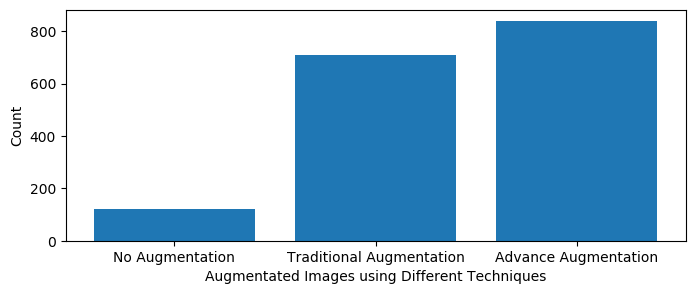

In [8]:
#images augmented size using without GAN, Traditional GAN and Advance GAN
height = [no_aug_X.shape[0], traditional_aug_X.shape[0], advance_aug_X.shape[0]]
bars = ['No Augmentation', 'Traditional Augmentation', 'Advance Augmentation']
y_pos = np.arange(len(bars))
plt.figure(figsize = (8, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Augmentated Images using Different Techniques")
plt.ylabel("Count")
plt.show()


In [9]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [10]:
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    
    conf_matrix = confusion_matrix(y_test, predict) 
    plt.figure(figsize =(6, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.xticks(rotation=90)
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()    



CNN Without GAN Accuracy  :  83.33333333333334
CNN Without GAN Precision : 82.01058201058201
CNN Without GAN Recall    : 87.2053872053872
CNN Without GAN FScore    : 81.94222931065038


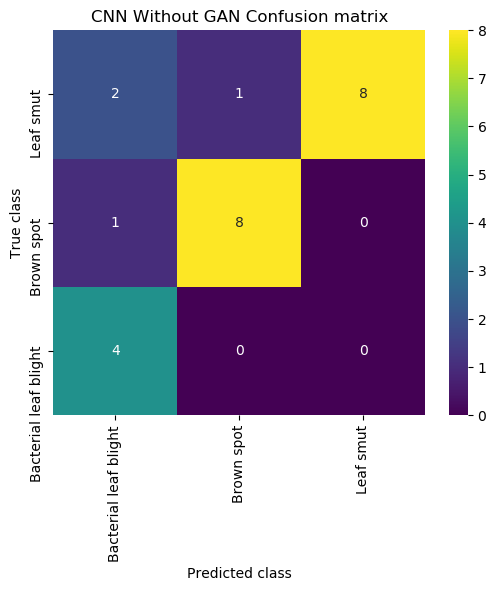

In [11]:
#preprocess images like shuffling and normalization
no_aug_X = no_aug_X.astype('float32')
no_aug_X = no_aug_X / 255 #normalized pixel values between 0 and 1
indices = np.arange(no_aug_X.shape[0])
np.random.shuffle(indices) #shuffle all images
no_aug_X = no_aug_X[indices]
no_aug_Y = no_aug_Y[indices]
no_aug_Y = to_categorical(no_aug_Y)
X_train, X_test, y_train, y_test = train_test_split(no_aug_X, no_aug_Y, test_size=0.2) #split dataset into train and test
#train CNN algorithm on with NO Augmentation Dataset
without_gan_model = Sequential()
#defining CNN layer with 32 filters of 3 X # matrix for features filtration
without_gan_model.add(Convolution2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
#max layer to collected relevant filtered features from Previous CNN layer
without_gan_model.add(MaxPooling2D(pool_size = (2, 2)))
#defining another CNN layer for further features optimization
without_gan_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
#collect relevant features
without_gan_model.add(MaxPooling2D(pool_size = (2, 2)))
#change features dimension to single dimension
without_gan_model.add(Flatten())
#define output layer
without_gan_model.add(Dense(units = 256, activation = 'relu'))
without_gan_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compile, train and load model
without_gan_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/without_gan_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/without_gan_weights.hdf5', verbose = 1, save_best_only = True)
    hist = without_gan_model.fit(X_train, y_train, batch_size = 16, epochs = 50, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/without_gan_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    without_gan_model.load_weights("model/without_gan_weights.hdf5")
#perform prediction on test images   
predict = without_gan_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("CNN Without GAN", predict, y_test1)

CNN With Traditional GAN Accuracy  :  94.36619718309859
CNN With Traditional GAN Precision : 94.40644474844201
CNN With Traditional GAN Recall    : 94.77406830805896
CNN With Traditional GAN FScore    : 94.4110977724423


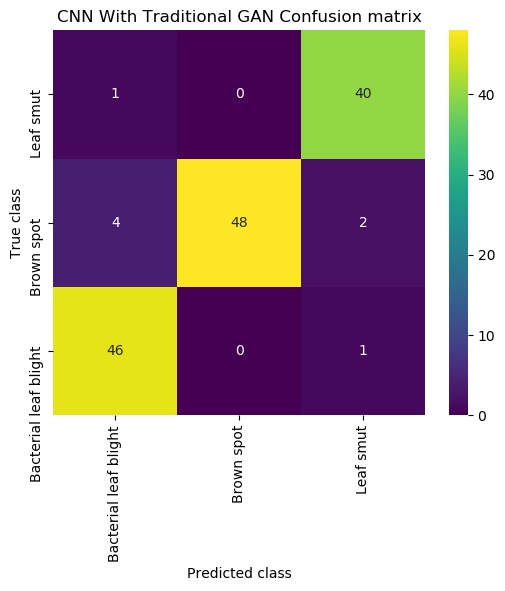

In [12]:
#traditional GAN training with CNN
#preprocess images like shuffling and normalization
traditional_aug_X = traditional_aug_X.astype('float32')
traditional_aug_X = traditional_aug_X / 255 #normalized pixel values between 0 and 1
indices = np.arange(traditional_aug_X.shape[0])
np.random.shuffle(indices) #shuffle all images
traditional_aug_X = traditional_aug_X[indices]
traditional_aug_Y = traditional_aug_Y[indices]
traditional_aug_Y = to_categorical(traditional_aug_Y)
X_train, X_test, y_train, y_test = train_test_split(traditional_aug_X, traditional_aug_Y, test_size=0.2) #split dataset into train and test
#train CNN algorithm on with Traditional Augmentation Dataset
traditionl_model = Sequential()
traditionl_model.add(Convolution2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
traditionl_model.add(MaxPooling2D(pool_size = (2, 2)))
traditionl_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
traditionl_model.add(MaxPooling2D(pool_size = (2, 2)))
traditionl_model.add(Flatten())
traditionl_model.add(Dense(units = 256, activation = 'relu'))
traditionl_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
traditionl_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/traditional_gan_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/traditional_gan_weights.hdf5', verbose = 1, save_best_only = True)
    hist = traditionl_model.fit(X_train, y_train, batch_size = 16, epochs = 50, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/traditional_gan_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    traditionl_model.load_weights("model/traditional_gan_weights.hdf5")
#perform prediction on test images    
predict = traditionl_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("CNN With Traditional GAN", predict, y_test1)

CNN With Advance GAN Accuracy  :  96.42857142857143
CNN With Advance GAN Precision : 96.20208992426421
CNN With Advance GAN Recall    : 96.52210983219005
CNN With Advance GAN FScore    : 96.31083742964762


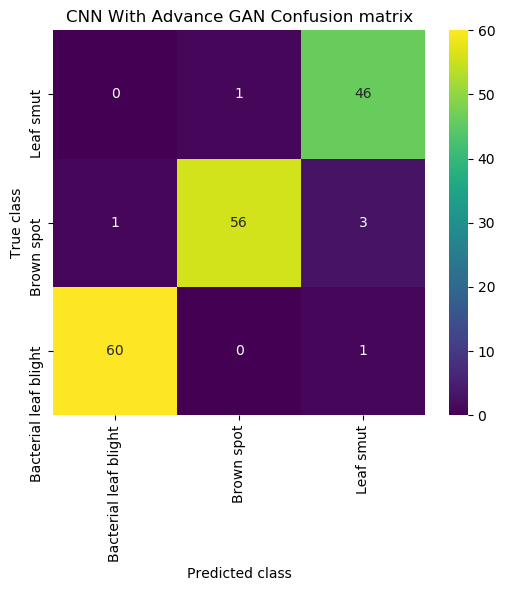

In [13]:
#traditional GAN training with CNN
#preprocess images like shuffling and normalization
advance_aug_X = advance_aug_X.astype('float32')
advance_aug_X = advance_aug_X / 255 #normalized pixel values between 0 and 1
indices = np.arange(advance_aug_X.shape[0])
np.random.shuffle(indices) #shuffle all images
advance_aug_X = advance_aug_X[indices]
advance_aug_Y = advance_aug_Y[indices]
advance_aug_Y = to_categorical(advance_aug_Y)
X_train, X_test, y_train, y_test = train_test_split(advance_aug_X, advance_aug_Y, test_size=0.2) #split dataset into train and test
#train CNN algorithm on with Advance Augmentation Dataset
advance_model = Sequential()
advance_model.add(Convolution2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
advance_model.add(MaxPooling2D(pool_size = (2, 2)))
advance_model.add(Dropout(0.2))
advance_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
advance_model.add(MaxPooling2D(pool_size = (2, 2)))
advance_model.add(Dropout(0.2))
advance_model.add(Flatten())
advance_model.add(Dense(units = 256, activation = 'relu'))
advance_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
advance_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/advance_gan_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/advance_gan_weights.hdf5', verbose = 1, save_best_only = True)
    hist = advance_model.fit(X_train, y_train, batch_size = 16, epochs = 50, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/advance_gan_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    advance_model.load_weights("model/advance_gan_weights.hdf5")
#perform prediction on test images    
predict = advance_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("CNN With Advance GAN", predict, y_test1)

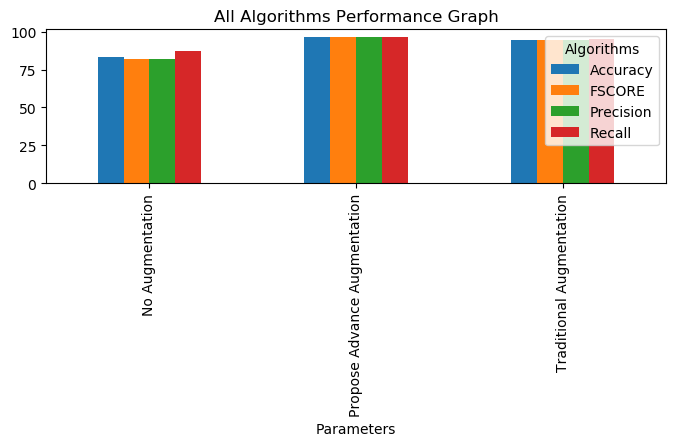

In [14]:
#comparison graph
import pandas as pd
df = pd.DataFrame([['No Augmentation','Accuracy',accuracy[0]],['No Augmentation','Precision',precision[0]],['No Augmentation','Recall',recall[0]],['No Augmentation','FSCORE',fscore[0]],
                   ['Traditional Augmentation','Accuracy',accuracy[1]],['Traditional Augmentation','Precision',precision[1]],['Traditional Augmentation','Recall',recall[1]],['Traditional Augmentation','FSCORE',fscore[1]],
                   ['Propose Advance Augmentation','Accuracy',accuracy[2]],['Propose Advance Augmentation','Precision',precision[2]],['Propose Advance Augmentation','Recall',recall[2]],['Propose Advance Augmentation','FSCORE',fscore[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 2))
plt.title("All Algorithms Performance Graph")
plt.show()

In [15]:
#display all algorithm performnace
algorithms = ['No Augmentation', 'Traditional Augmentation', 'Propose Advance Augmentation']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,No Augmentation,83.333333,82.010582,87.205387,81.942229
1,Traditional Augmentation,94.366197,94.406445,94.774068,94.411098
2,Propose Advance Augmentation,96.428571,96.202090,96.522110,96.310837


In [16]:
#use this function to predict fish species uisng extension model
def predictCropHealth(image_path):
    image = cv2.imread(image_path)#read test image
    img = cv2.resize(image, (32, 32))#resize image
    im2arr = np.array(img)
    im2arr = im2arr.reshape(1,32,32,3)#convert image as 4 dimension
    img = np.asarray(im2arr)
    img = img.astype('float32')#convert image features as float
    img = img/255 #normalized image
    predict = advance_model.predict(img)#perform prediction on test image using advance model
    predict = np.argmax(predict)
    img = cv2.imread(image_path)#read test image
    img = cv2.resize(img, (400,300))#display image with predicted output
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cv2.putText(img, 'Predicted As : '+labels[predict], (10, 25),  cv2.FONT_HERSHEY_SIMPLEX,0.7, (0, 0, 255), 2)
    plt.figure(figsize=(4,3))
    plt.imshow(img)

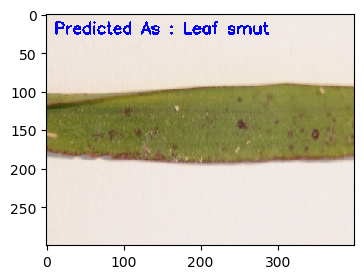

In [20]:
#call this function with image path to predict crop health
predictCropHealth("testImages/2.jpg")

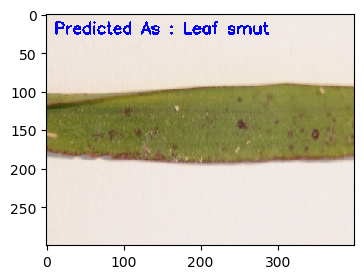

In [22]:
#call this function with image path to predict crop health
predictCropHealth("testImages/2.jpg")

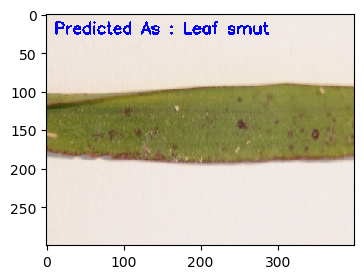

In [19]:
#call this function with image path to predict crop health
predictCropHealth("testImages/4.jpg")